In [1]:
# ─────────────────────────────────────────────
# CELL 1 — Imports & Data Loading
# ─────────────────────────────────────────────

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv("uae_real_estate_2024.csv")

# Basic overview
print("Shape:", df.shape)
print("\nColumn names:", df.columns.tolist())
print("\nData types:\n", df.dtypes)
print("\nFirst 3 rows:")
df.head(3)

Shape: (5058, 12)

Column names: ['title', 'displayAddress', 'bathrooms', 'bedrooms', 'addedOn', 'type', 'price', 'verified', 'priceDuration', 'sizeMin', 'furnishing', 'description']

Data types:
 title             object
displayAddress    object
bathrooms         object
bedrooms          object
addedOn           object
type              object
price              int64
verified            bool
priceDuration     object
sizeMin           object
furnishing        object
description       object
dtype: object

First 3 rows:


,title,displayAddress,bathrooms,bedrooms,addedOn,type,price,verified,priceDuration,sizeMin,furnishing,description
0,Great ROI I High Floor I Creek View,"Binghatti Canal, Business Bay, Dubai",3,2,2024-08-14T12:02:53Z,Residential for Sale,2500000,True,sell,1323 sqft,NO,MNA Properties is delighted to offer this apar...
1,Full Sea View | Beach Life | Brand New Residence,"La Vie, Jumeirah Beach Residence, Dubai",3,2,2024-08-13T05:45:16Z,Residential for Sale,7200000,True,sell,1410 sqft,YES,"Apartment for sale in La Vie, Jumeirah Beach R..."
2,Green Belt | Corner Unit | Spacious Plot,"La Rosa 6, Villanova, Dubai Land, Dubai",3,4,2024-08-14T06:24:28Z,Residential for Sale,3600000,True,sell,2324 sqft,NO,Treo Homes is very pleased to be bringing to t...


In [2]:
# ─────────────────────────────────────────────
# CELL 2 — Missing Values & Duplicates Check
# ─────────────────────────────────────────────

# Check for missing values
print("=== Missing Values ===")
print(df.isnull().sum())
print(f"\nTotal missing: {df.isnull().sum().sum()}")

# Check for duplicate rows
print(f"\n=== Duplicate Rows ===")
print(f"Number of duplicates: {df.duplicated().sum()}")

# Drop duplicates if any
df = df.drop_duplicates()
print(f"Shape after dropping duplicates: {df.shape}")

=== Missing Values ===
title               0
displayAddress      0
bathrooms         120
bedrooms          123
addedOn             0
type                0
price               0
verified            0
priceDuration       0
sizeMin             0
furnishing          2
description         1
dtype: int64

Total missing: 246

=== Duplicate Rows ===
Number of duplicates: 0
Shape after dropping duplicates: (5058, 12)


In [3]:
# ─────────────────────────────────────────────
# CELL 3 — Drop Useless Columns & Fix Data Types
# ─────────────────────────────────────────────

# Drop columns with only 1 unique value — no predictive power
# 'type' is always "Residential for Sale", 'priceDuration' is always "sell"
df = df.drop(columns=['type', 'priceDuration'])
print("Dropped 'type' and 'priceDuration' (constant columns)")

# Drop 'title' and 'description' — free text, not useful for regression directly
df = df.drop(columns=['title', 'description'])
print("Dropped 'title' and 'description' (unstructured text)")

# Fix 'sizeMin': remove " sqft" and convert to numeric
df['sizeMin'] = df['sizeMin'].str.replace(' sqft', '', regex=False)
df['sizeMin'] = pd.to_numeric(df['sizeMin'], errors='coerce')
print("\n'sizeMin' converted to numeric")

# Fix 'addedOn': parse datetime and extract month (seasonality signal)
df['addedOn'] = pd.to_datetime(df['addedOn'], utc=True)
df['month_listed'] = df['addedOn'].dt.month
df = df.drop(columns=['addedOn'])
print("'addedOn' parsed — extracted 'month_listed', original column dropped")

# Fix 'bathrooms' and 'bedrooms': they loaded as object, convert to numeric
df['bathrooms'] = pd.to_numeric(df['bathrooms'], errors='coerce')
df['bedrooms'] = pd.to_numeric(df['bedrooms'], errors='coerce')
print("'bathrooms' and 'bedrooms' converted to numeric")

print("\n=== Updated dtypes ===")
print(df.dtypes)
print("\nShape:", df.shape)

Dropped 'type' and 'priceDuration' (constant columns)
Dropped 'title' and 'description' (unstructured text)

'sizeMin' converted to numeric
'addedOn' parsed — extracted 'month_listed', original column dropped
'bathrooms' and 'bedrooms' converted to numeric

=== Updated dtypes ===
displayAddress     object
bathrooms         float64
bedrooms          float64
price               int64
verified             bool
sizeMin             int64
furnishing         object
month_listed        int32
dtype: object

Shape: (5058, 8)


In [4]:
# ─────────────────────────────────────────────
# CELL 4 — Handle Missing Values
# ─────────────────────────────────────────────

# 'bathrooms' and 'bedrooms': impute with median (robust to outliers)
df['bathrooms'] = df['bathrooms'].fillna(df['bathrooms'].median())
df['bedrooms'] = df['bedrooms'].fillna(df['bedrooms'].median())
print(f"'bathrooms' median imputed: {df['bathrooms'].median()}")
print(f"'bedrooms' median imputed:  {df['bedrooms'].median()}")

# 'furnishing': impute with mode (most frequent category)
furnishing_mode = df['furnishing'].mode()[0]
df['furnishing'] = df['furnishing'].fillna(furnishing_mode)
print(f"'furnishing' mode imputed: '{furnishing_mode}'")

# Verify no missing values remain
print("\n=== Missing Values After Imputation ===")
print(df.isnull().sum())

'bathrooms' median imputed: 3.0
'bedrooms' median imputed:  2.0
'furnishing' mode imputed: 'NO'

=== Missing Values After Imputation ===
displayAddress    0
bathrooms         0
bedrooms          0
price             0
verified          0
sizeMin           0
furnishing        0
month_listed      0
dtype: int64


In [5]:
# ─────────────────────────────────────────────
# CELL 5 — Encode Categorical Variables
# ─────────────────────────────────────────────

# 'verified': convert bool to int (True=1, False=0)
df['verified'] = df['verified'].astype(int)
print("'verified' encoded: True→1, False→0")

# 'furnishing': one-hot encode (NO / YES / PARTLY)
# drop_first=False so all 3 categories are visible and explainable
df = pd.get_dummies(df, columns=['furnishing'], prefix='furnished')
print("'furnishing' one-hot encoded into columns:",
      [c for c in df.columns if c.startswith('furnished')])

# 'displayAddress': extract the city/area (last part after last comma)
# e.g. "Binghatti Canal, Business Bay, Dubai" → "Dubai"
df['city'] = df['displayAddress'].str.split(',').str[-1].str.strip()
print(f"\nUnique cities extracted: {df['city'].nunique()}")
print(df['city'].value_counts().head(10))

# Label encode 'city' (too many unique values for one-hot)
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['city_encoded'] = le.fit_transform(df['city'])
df = df.drop(columns=['displayAddress', 'city'])
print("\n'displayAddress' → label-encoded as 'city_encoded', original dropped")

print("\n=== Final Columns ===")
print(df.columns.tolist())
print("\nShape:", df.shape)

'verified' encoded: True→1, False→0
'furnishing' one-hot encoded into columns: ['furnished_NO', 'furnished_PARTLY', 'furnished_YES']

Unique cities extracted: 8
city
Dubai             4031
Abu Dhabi          370
Sharjah            267
Ras Al Khaimah     201
Ajman              170
Umm Al Quwain       11
Fujairah             4
Al Ain               4
Name: count, dtype: int64

'displayAddress' → label-encoded as 'city_encoded', original dropped

=== Final Columns ===
['bathrooms', 'bedrooms', 'price', 'verified', 'sizeMin', 'month_listed', 'furnished_NO', 'furnished_PARTLY', 'furnished_YES', 'city_encoded']

Shape: (5058, 10)


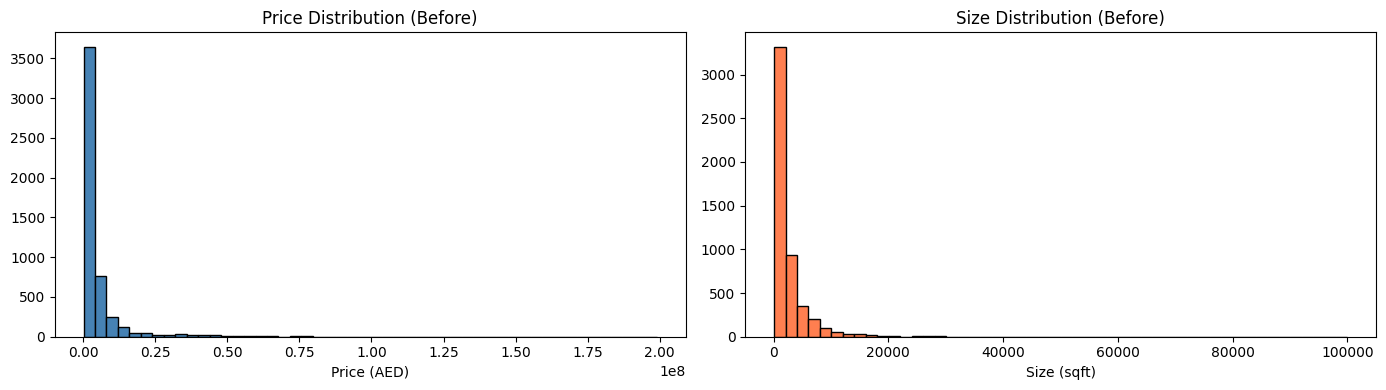

'price': removed 539 outliers | range kept: [-3,749,062 – 9,448,438]
'sizeMin': removed 310 outliers | range kept: [-1,415 – 4,403]

Shape after outlier removal: (4209, 10)


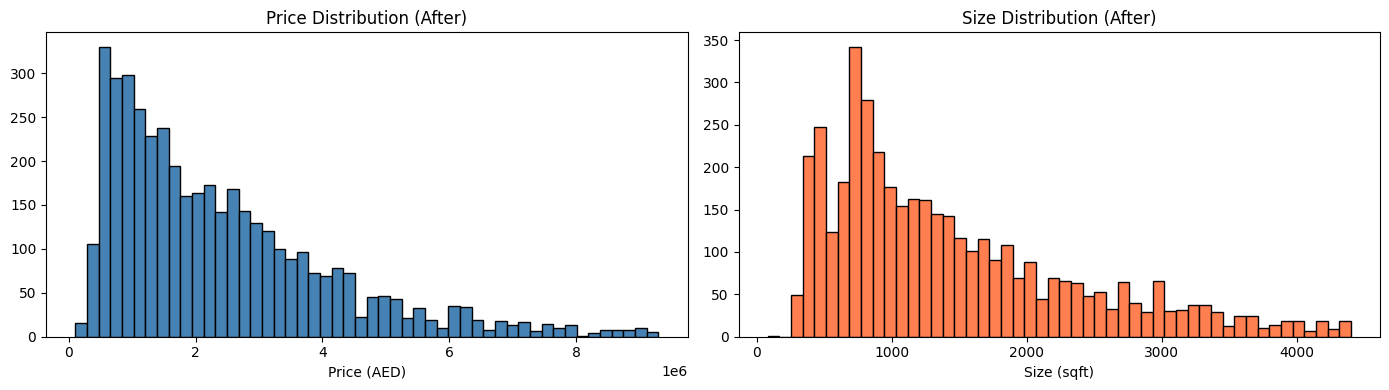

In [6]:
# ─────────────────────────────────────────────
# CELL 6 — Outlier Detection & Removal
# ─────────────────────────────────────────────

# Visualize price and sizeMin distributions before removing outliers
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df['price'], bins=50, color='steelblue', edgecolor='black')
axes[0].set_title('Price Distribution (Before)')
axes[0].set_xlabel('Price (AED)')

axes[1].hist(df['sizeMin'], bins=50, color='coral', edgecolor='black')
axes[1].set_title('Size Distribution (Before)')
axes[1].set_xlabel('Size (sqft)')

plt.tight_layout()
plt.show()

# Use IQR method to remove outliers from 'price' and 'sizeMin'
def remove_outliers_iqr(dataframe, column):
    Q1 = dataframe[column].quantile(0.25)
    Q3 = dataframe[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    before = len(dataframe)
    dataframe = dataframe[(dataframe[column] >= lower) & (dataframe[column] <= upper)]
    print(f"'{column}': removed {before - len(dataframe)} outliers | range kept: [{lower:,.0f} – {upper:,.0f}]")
    return dataframe

df = remove_outliers_iqr(df, 'price')
df = remove_outliers_iqr(df, 'sizeMin')

print(f"\nShape after outlier removal: {df.shape}")

# Visualize after
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df['price'], bins=50, color='steelblue', edgecolor='black')
axes[0].set_title('Price Distribution (After)')
axes[0].set_xlabel('Price (AED)')

axes[1].hist(df['sizeMin'], bins=50, color='coral', edgecolor='black')
axes[1].set_title('Size Distribution (After)')
axes[1].set_xlabel('Size (sqft)')

plt.tight_layout()
plt.show()

In [7]:
# ─────────────────────────────────────────────
# CELL 7 — Feature Scaling & Final Export
# ─────────────────────────────────────────────

from sklearn.preprocessing import StandardScaler

# Separate features and target
X = df.drop(columns=['price'])
y = df['price']

# Scale only continuous numeric features (not binary/encoded columns)
cols_to_scale = ['bathrooms', 'bedrooms', 'sizeMin', 'month_listed']

scaler = StandardScaler()
X[cols_to_scale] = scaler.fit_transform(X[cols_to_scale])

print("=== Scaled Features (first 3 rows) ===")
print(X[cols_to_scale].head(3))

print("\n=== Final Feature Summary ===")
print(X.describe().round(2))

# Combine back for saving
df_clean = X.copy()
df_clean['price'] = y.values

# Save cleaned dataset
df_clean.to_csv('uae_real_estate_cleaned.csv', index=False)
print("\n✅ Cleaned dataset saved as 'uae_real_estate_cleaned.csv'")
print("Final shape:", df_clean.shape)

=== Scaled Features (first 3 rows) ===
   bathrooms  bedrooms   sizeMin  month_listed
0   0.274457 -0.159784 -0.134820      0.845741
1   0.274457 -0.159784 -0.040893      0.845741
2   0.274457  1.729342  0.945879      0.845741

=== Final Feature Summary ===
       bathrooms  bedrooms  verified  sizeMin  month_listed  city_encoded
count    4209.00   4209.00   4209.00  4209.00       4209.00       4209.00
mean       -0.00     -0.00      0.67    -0.00         -0.00          2.98
std         1.00      1.00      0.47     1.00          1.00          1.18
min        -1.17     -1.10      0.00    -1.47         -4.18          0.00
25%        -0.45     -1.10      0.00    -0.75         -0.59          3.00
50%        -0.45     -0.16      1.00    -0.29          0.13          3.00
75%         0.27      0.78      1.00     0.52          0.85          3.00
max         3.15      4.56      1.00     3.19          3.72          7.00

✅ Cleaned dataset saved as 'uae_real_estate_cleaned.csv'
Final shape: (4209